# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели


Часть 1. EDA 

Распределение признаков: 
- Цены имеют сильную правостороннюю асимметрию (большинство объявлений дешевые, а дорогих — мало).
- Большинство объявлений требуют минимального бронирования на 1-2 ночи. 
- Количество отзывов и отзывов в месяц сильно скошены вправо, что говорит о том, что у большинства объектов мало отзывов, а у небольшого числа — очень много.

Корреляции: 
- Корреляции между числовыми признаками слабые (< 0.3), что говорит об отсутствии сильной мультиколлинеарности. 
- Есть слабая положительная связь между количеством объявлений хозяина и доступностью, а также между отзывами и количеством объявлений. 
- Географические координаты практически не коррелируют с ценой.

Категориальные признаки: 
- Анализ цен по районам (neighbourhood_group) и типам жилья (room_type) показывает, что Манхэттен является самым дорогим районом, а аренда целого жилья значительно дороже, чем отдельных комнат. Это указывает на важность этих признаков для предсказания цены.



     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

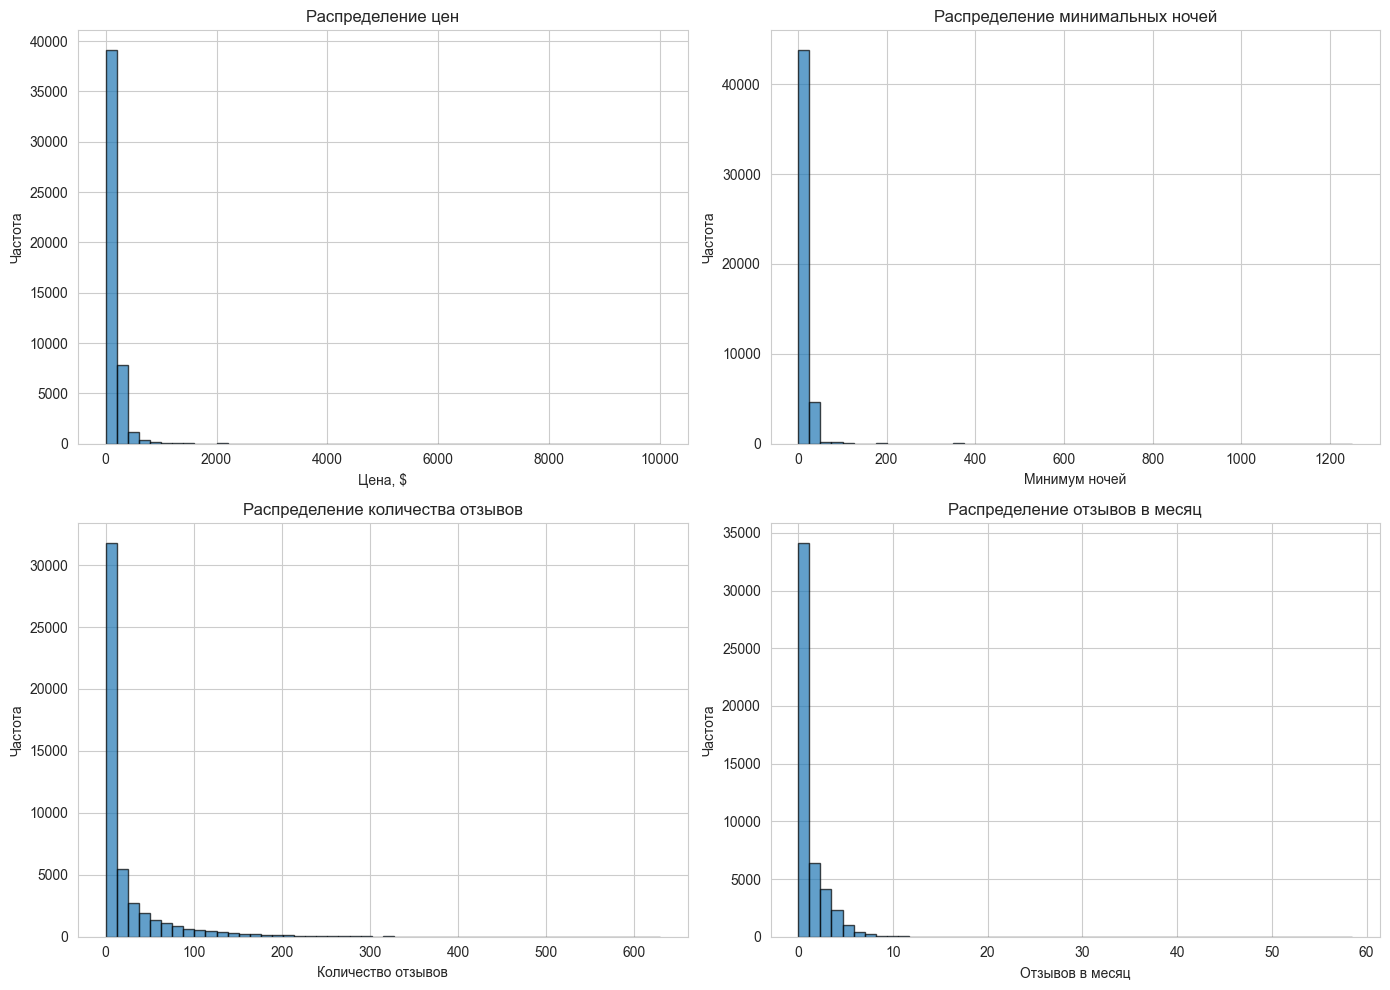

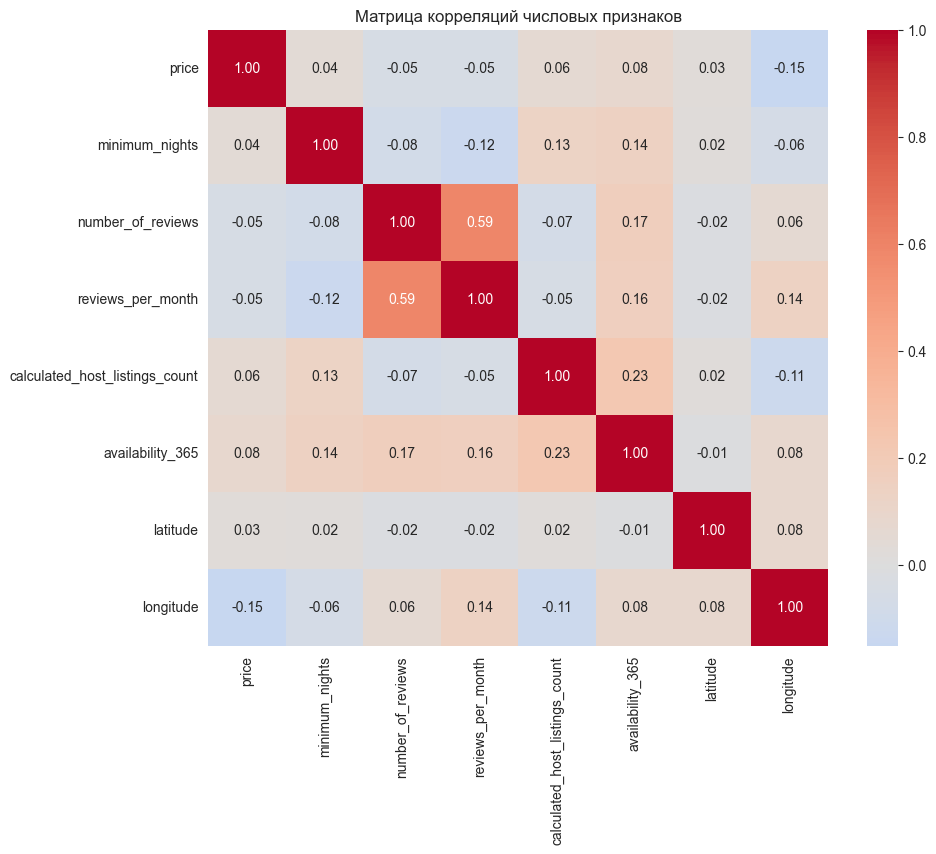

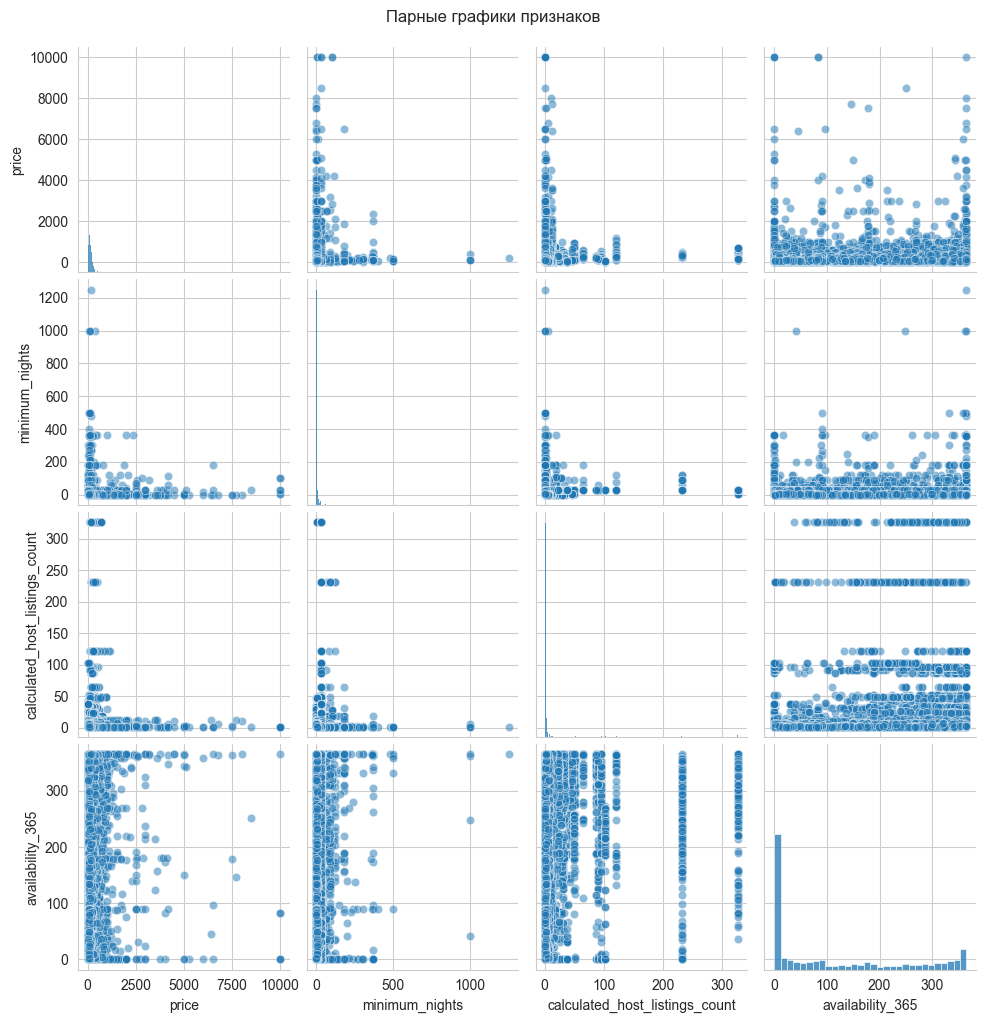

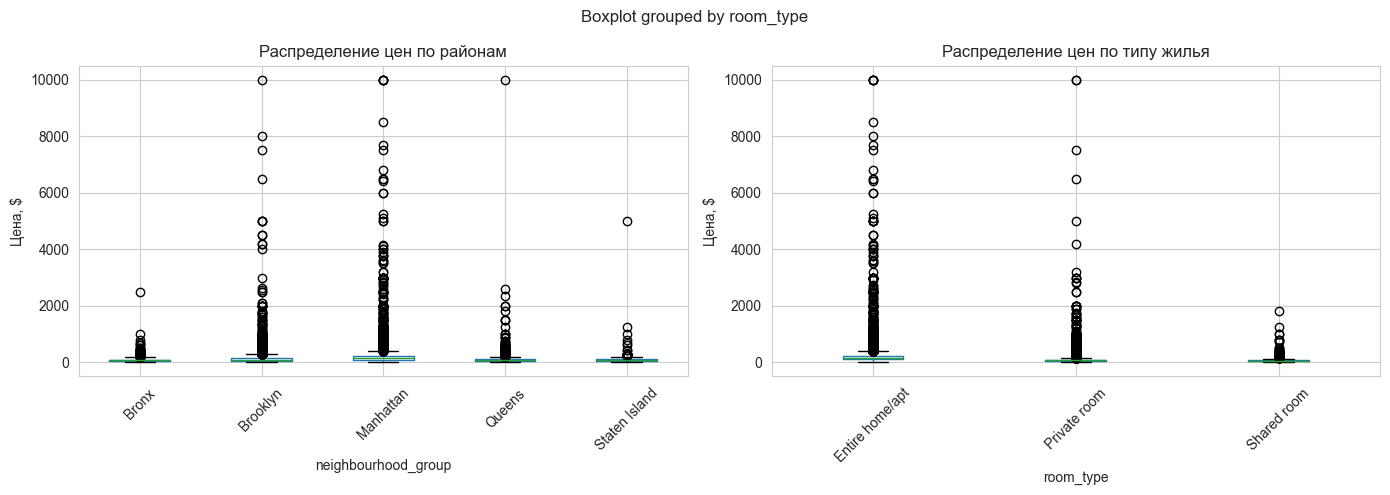

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, RobustScaler

# Настройка визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Загрузка данных
df = pd.read_csv('AB_NYC_2019.csv')
print(df.head())

#  Удаление ненужных признаков
df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'], inplace=True)

# Анализ пропусков
print(df.isnull().sum())

# Заполняем reviews_per_month нулями (нет отзывов → 0 отзывов в месяц)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Визуализация распределений признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Цена
axes[0, 0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение цен')
axes[0, 0].set_xlabel('Цена, $')
axes[0, 0].set_ylabel('Частота')

# Минимальное количество ночей
axes[0, 1].hist(df['minimum_nights'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение минимальных ночей')
axes[0, 1].set_xlabel('Минимум ночей')
axes[0, 1].set_ylabel('Частота')

# Количество отзывов
axes[1, 0].hist(df['number_of_reviews'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение количества отзывов')
axes[1, 0].set_xlabel('Количество отзывов')
axes[1, 0].set_ylabel('Частота')

# Отзывы в месяц
axes[1, 1].hist(df['reviews_per_month'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение отзывов в месяц')
axes[1, 1].set_xlabel('Отзывов в месяц')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Матрица корреляций
numeric_features = ['price', 'minimum_nights', 'number_of_reviews', 
                   'reviews_per_month', 'calculated_host_listings_count', 
                   'availability_365', 'latitude', 'longitude']

plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.show()

# Pair plots для выбранных признаков
features_to_plot = ['price', 'minimum_nights', 'calculated_host_listings_count', 'availability_365']
sns.pairplot(df[features_to_plot], plot_kws={'alpha': 0.5})
plt.suptitle('Парные графики признаков', y=1.02)
plt.show()

# Анализ цен по категориям
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По районам
df.boxplot(column='price', by='neighbourhood_group', ax=axes[0])
axes[0].set_title('Распределение цен по районам')
axes[0].set_ylabel('Цена, $')
axes[0].tick_params(axis='x', rotation=45)

# По типу жилья
df.boxplot(column='price', by='room_type', ax=axes[1])
axes[1].set_title('Распределение цен по типу жилья')
axes[1].set_ylabel('Цена, $')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Часть 2. Preprocessing & Feature Engineering
- Удаление выбросов: 
Применение метода IQR для удаления аномально высоких цен (выбросов) привело к улучшению качества модели, так как модель перестала пытаться предсказывать экстремальные значения.

- Логарифмирование целевой переменной: 
Преобразование цены с помощью np.log1p дало ключевое улучшение. Распределение стало значительно ближе к нормальному, что положительно сказалось на качестве всех линейных моделей.

- Создание новых признаков:
distance_to_manhattan (расстояние до Манхэттена) — значимый признак, отражающий географическую премиальность.
price_per_night (цена за ночь) — один из самых важных признаков, так как он нормализует стоимость относительно минимального срока аренды.
avg_price_by_neighbourhood (средняя цена по району) — полезный категориальный агрегат.

- Масштабирование: 
Использование RobustScaler для признаков с выбросами (minimum_nights, calculated_host_listings_count) и StandardScaler для остальных признаков позволило корректно обучить модели, чувствительные к масштабу

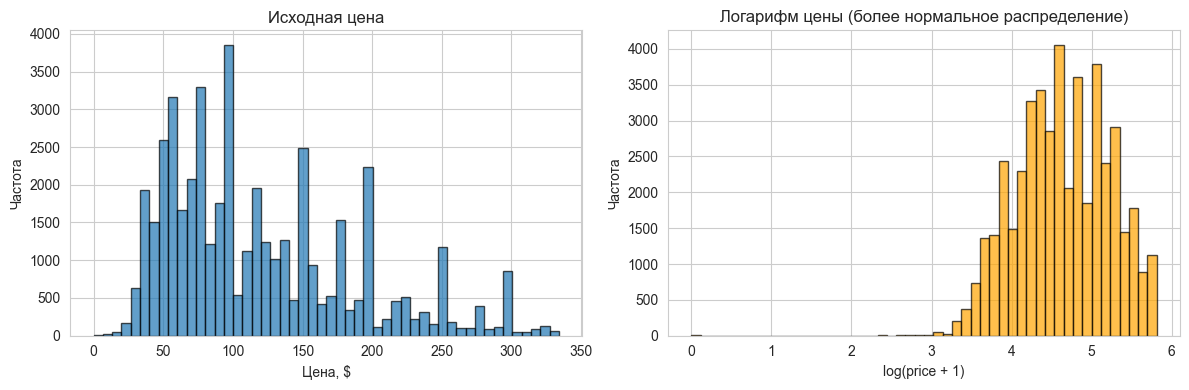

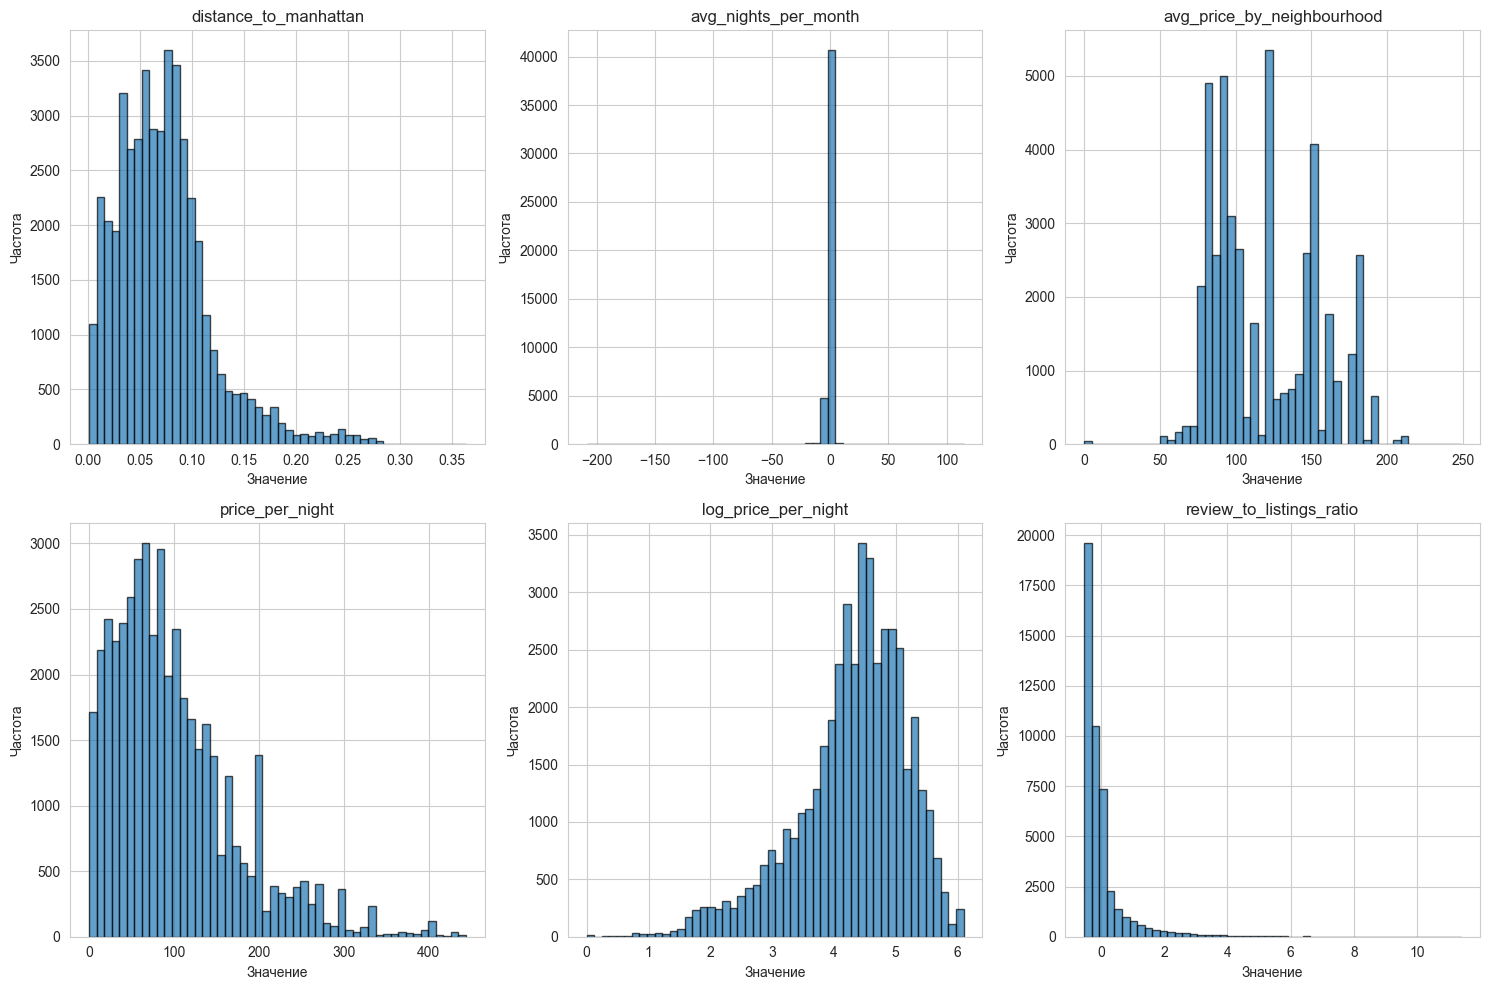

   distance_to_manhattan: -0.3711
   avg_nights_per_month: -0.0220
   avg_price_by_neighbourhood: 0.5004
   price_per_night: 0.6933
   log_price_per_night: 0.5450
   review_to_listings_ratio: 0.0103
   distance_availability: 0.0140
   distance_squared: -0.2583
   review_density: -0.0212

   Топ-3 новых признака по корреляции с ценой:
   1. price_per_night: 0.6933
   2. log_price_per_night: 0.5450
   3. avg_price_by_neighbourhood: 0.5004


In [36]:
df = df.copy()

categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 1.5 * IQR)]

# Преобразование целевой переменной (логарифмирование)
df['price_log'] = np.log1p(df['price'])

# Сравнение распределений до и после логарифмирования
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Исходная цена', fontsize=12)
axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Частота')

axes[1].hist(df['price_log'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Логарифм цены (более нормальное распределение)', fontsize=12)
axes[1].set_xlabel('log(price + 1)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Масштабирование числовых признаков

# RobustScaler для признаков с выбросами
robust_features = ['minimum_nights', 'calculated_host_listings_count']
scaler_robust = RobustScaler()
df[robust_features] = scaler_robust.fit_transform(df[robust_features])

# StandardScaler для нормальных признаков
std_features = ['number_of_reviews', 'reviews_per_month', 'availability_365']
scaler_std = StandardScaler()
df[std_features] = scaler_std.fit_transform(df[std_features])

# Создание новых признаков

# 1. Расстояние до Манхэттена
manhattan_lat, manhattan_lon = 40.7580, -73.9855
df['distance_to_manhattan'] = np.sqrt(
    (df['latitude'] - manhattan_lat)**2 + 
    (df['longitude'] - manhattan_lon)**2
)

# 2. Среднее количество ночей в месяц
df['avg_nights_per_month'] = df['minimum_nights'] * df['reviews_per_month']

# 3. Средняя цена по району 
neighbourhood_cols = [col for col in df.columns if col.startswith('neighbourhood_') and 'group' not in col]
df['avg_price_by_neighbourhood'] = 0

for col in neighbourhood_cols:
    col_float = df[col].astype(float)
    avg_price = df.groupby(col)['price'].transform('mean')
    df['avg_price_by_neighbourhood'] += col_float * avg_price

# 4 Цена за ночь
df['price_per_night'] = df['price'] / (df['minimum_nights'] + 1)

# 5 Логарифм цены за ночь
df['log_price_per_night'] = np.log1p(df['price_per_night'])

# 6 Соотношение отзывов к объявлениям хозяина
df['review_to_listings_ratio'] = df['number_of_reviews'] / (df['calculated_host_listings_count'] + 1)

# 7 Взаимодействие расстояния и доступности
df['distance_availability'] = df['distance_to_manhattan'] * df['availability_365']

# 8 Квадрат расстояния (нелинейная зависимость)
df['distance_squared'] = df['distance_to_manhattan'] ** 2

# 9 Плотность отзывов
df['review_density'] = df['reviews_per_month'] * df['availability_365']

# Визуализация новых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

new_features_basic = [
    'distance_to_manhattan', 
    'avg_nights_per_month', 
    'avg_price_by_neighbourhood',
    'price_per_night', 
    'log_price_per_night', 
    'review_to_listings_ratio'
]

for i, feature in enumerate(new_features_basic):
    ax = axes[i//3, i%3]
    ax.hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(feature, fontsize=12)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Анализ корреляции новых признаков

new_features_all = [
    'distance_to_manhattan', 
    'avg_nights_per_month', 
    'avg_price_by_neighbourhood',
    'price_per_night', 
    'log_price_per_night', 
    'review_to_listings_ratio',
    'distance_availability', 
    'distance_squared', 
    'review_density'
]

correlations = {}
for feature in new_features_all:
    corr = np.corrcoef(df[feature], df['price'])[0, 1]
    correlations[feature] = corr
    print(f"   {feature}: {corr:.4f}")

# Сортировка по абсолютной корреляции
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print("\n   Топ-3 новых признака по корреляции с ценой:")
for i, (feature, corr) in enumerate(sorted_corr[:3], 1):
    print(f"   {i}. {feature}: {corr:.4f}")

Часть 3. Моделирование
- Лучшая модель: 
RidgeCV показала лучший результат с R² = 0.7676, что означает, что модель объясняет ~76.8% дисперсии цены на тестовых данных. Это хороший результат для предсказания цен на недвижимость.

- Ошибки: 
Средняя абсолютная ошибка (MAE) в логарифмическом масштабе составила ~0.20. В реальных деньгах это соответствует средней ошибке около $36.00. Относительная ошибка (MAPE) составила 32.07%.

Стоит отметить, что все модели показали схожее качество (R² > 0.76), что говорит о стабильности предсказаний. 

- Выводы по важности признаков:
   Анализ коэффициентов лучшей модели (RidgeCV) показал, что наибольшее влияние на цену оказывают:
   * Цена за ночь (price_per_night): Логичный признак, так как напрямую отражает стоимость аренды.
   * Расстояние до Манхэттена (distance_to_manhattan): Отрицательное влияние (чем дальше, тем дешевле).
   * Тип жилья (room_type_Private room, room_type_Shared room): Отрицательное влияние по сравнению с арендой целого жилья.
   * Минимальное количество ночей (minimum_nights): Положительное влияние (возможно, на короткий срок цена выше).
   * Средняя цена по району (avg_price_by_neighbourhood): Положительное влияние.
Это подтверждает, что геолокация, тип жилья и стоимость за ночь являются ключевыми драйверами цены.

Размер обучающей выборки: (32146, 242)
Размер тестовой выборки: (13777, 242)
  Linear Regression...   RidgeCV...   LassoCV...   ElasticNetCV... 
РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ
                       R2  MAE_log  RMSE_log    MAE_$     RMSE_$   MAPE_%
Linear Regression  0.7675   0.2005    0.2750  36.1223  1001.1159  32.2051
RidgeCV            0.7676   0.2005    0.2749  36.0015   989.8397  32.0709
LassoCV            0.7664   0.2057    0.2756  27.9006   317.6934  23.1583
ElasticNetCV       0.7674   0.2037    0.2751  29.3050   440.6463  24.2450

ЛУЧШАЯ МОДЕЛЬ: RidgeCV
R² = 0.7676 — модель объясняет 76.8% дисперсии
MAE в логарифмах = 0.2005
Средняя абсолютная ошибка = $36.00
Относительная ошибка (MAPE) = 32.1%


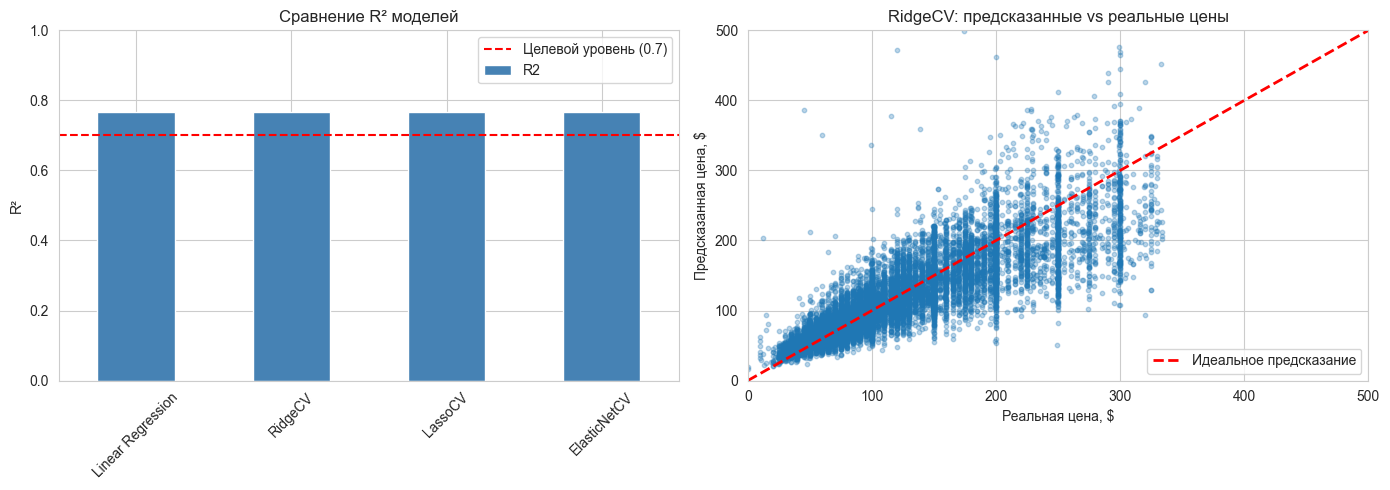


ТОП-10 ВАЖНЫХ ПРИЗНАКОВ
  238. log_price_per_night: 0.2329 (положительное влияние)
  234. distance_to_manhattan: 0.2299 (отрицательное влияние)
  232. room_type_Private room: 0.2202 (отрицательное влияние)
  3. minimum_nights: 0.1525 (положительное влияние)
  241. distance_squared: 0.1459 (положительное влияние)
  233. room_type_Shared room: 0.1153 (отрицательное влияние)
  237. price_per_night: 0.1152 (положительное влияние)
  7. availability_365: 0.0833 (положительное влияние)
  235. avg_nights_per_month: 0.0472 (положительное влияние)
  5. reviews_per_month: 0.0452 (отрицательное влияние)


In [37]:
X = df.drop(['price', 'price_log'], axis=1)
y = df['price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Масштабирование
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение моделей
models = {
    'Linear Regression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]), 
    'LassoCV': LassoCV(max_iter=10000, alphas=[0.01, 0.1, 1, 10]), 
    'ElasticNetCV': ElasticNetCV(max_iter=10000, alphas=[0.01, 0.1, 1, 10])
}

results = {}
for name, model in models.items():
    print(f"  {name}...", end=" ")
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred_log)
    mae_log = mean_absolute_error(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1))) * 100
    
    results[name] = {
        'R2': r2,
        'MAE_log': mae_log,
        'RMSE_log': rmse_log,
        'MAE_$': mae_real,
        'RMSE_$': rmse_real,
        'MAPE_%': mape
    }

# Результаты
results_df = pd.DataFrame(results).T
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ")
print("="*70)
print(results_df.round(4))

best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
best_results = results_df.loc[best_model_name]

print("\n" + "="*70)
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print("="*70)
print(f"R² = {best_results['R2']:.4f} — модель объясняет {best_results['R2']*100:.1f}% дисперсии")
print(f"MAE в логарифмах = {best_results['MAE_log']:.4f}")
print(f"Средняя абсолютная ошибка = ${best_results['MAE_$']:.2f}")
print(f"Относительная ошибка (MAPE) = {best_results['MAPE_%']:.1f}%")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['R2'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Сравнение R² моделей')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].axhline(y=0.7, color='red', linestyle='--', label='Целевой уровень (0.7)')
axes[0].legend()

best_model.fit(X_train_scaled, y_train)
y_pred_best_log = best_model.predict(X_test_scaled)
y_pred_best_real = np.expm1(y_pred_best_log)
y_test_best_real = np.expm1(y_test)

axes[1].scatter(y_test_best_real, y_pred_best_real, alpha=0.3, s=10)
axes[1].plot([0, 500], [0, 500], 'r--', lw=2, label='Идеальное предсказание')
axes[1].set_xlabel('Реальная цена, $')
axes[1].set_ylabel('Предсказанная цена, $')
axes[1].set_title(f'{best_model_name}: предсказанные vs реальные цены')
axes[1].set_xlim(0, 500)
axes[1].set_ylim(0, 500)
axes[1].legend()
plt.tight_layout()
plt.show()

# Важность признаков
if hasattr(best_model, 'coef_'):
    feature_names = X.columns
    coefficients = best_model.coef_
    
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coef': coefficients,
        'abs_coef': np.abs(coefficients)
    })
    coef_df = coef_df.sort_values('abs_coef', ascending=False)
    
    print("\n" + "="*70)
    print("ТОП-10 ВАЖНЫХ ПРИЗНАКОВ")
    print("="*70)
    for i, row in coef_df.head(10).iterrows():
        sign = "положительное" if row['coef'] > 0 else "отрицательное"
        print(f"  {i+1}. {row['feature']}: {row['abs_coef']:.4f} ({sign} влияние)")